# Setup

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Sizing according to Springer Guidelines ---
# Springer single-column width is typically ~84 mm (3.3 inches).
# Page width for 2 columns / maximum width is ~174 mm (6.85 inches).
# Let's target a clean 1.5-column or full-width figure that handles text gracefully.
fig_width_inch = 5.5 
fig_height_inch = 4.0

# Configure global font styles to match standard article typography
# Springer prefers Helvetica or Arial (sans-serif) or Times New Roman (serif)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 8,          # Minimum font size should be around 8pt (never below 6pt)
    'axes.labelsize': 9,     # Axis labels slightly larger
    'axes.titlesize': 10,    # Title size
    'legend.fontsize': 8,    # Legend text size
    'xtick.labelsize': 8,    # X-tick labels
    'ytick.labelsize': 8,    # Y-tick labels
    'figure.figsize': [fig_width_inch, fig_height_inch],
    'text.usetex': False     # Set to True if your environment has a LaTeX distribution
})

def export_plot(name, tiff=False):
  # --- 5. Exporting in High Resolution ---
  # Vector formats (PDF/EPS) are highly preferred by Springer for line graphs.
  # If saving as a raster image (TIFF/PNG), Springer requires a minimum of 600 to 1200 DPI for line art.

  # Option A: Save as vector graphic (Highly Recommended)
  plt.savefig(f"{name}.eps", format='eps', bbox_inches='tight')

  if tiff:
    # Option B: Save as high-resolution raster graphic
    plt.savefig(f"{name}.tiff", format='tiff', dpi=600, bbox_inches='tight')

  plt.show()
  
  print(f"Figures exported successfully as {name}.eps matching Springer guidelines.")

# CQT Spectrogram

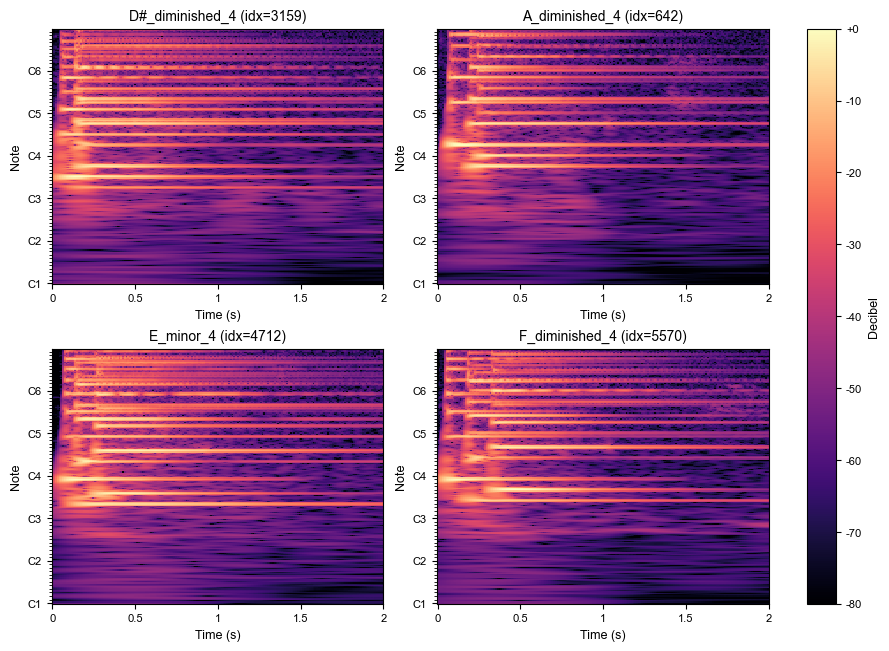

Figures exported successfully as cqt_spectrogram.eps matching Springer guidelines.


In [10]:
import os
import librosa
import librosa.display

# Load training features (notebook lives in notebooks/graphics/, so ../../ reaches training/)
features_path = os.path.join('..', '..', 'features', 'opus-training.npz')
if not os.path.exists(features_path):
    raise FileNotFoundError(f'Features file not found: {features_path}')

data = np.load(features_path)
features = np.asarray(data['features'])
labels = np.asarray(data['labels'])

# CQT parameters matching the dataset
fmin = librosa.note_to_hz('C1')
hop_length = 512
bins_per_octave = 36
sr = 48_000

# Pick 4 random samples
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(features), size=4, replace=False)

# Plot 4 CQT spectrograms in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(fig_width_inch * 1.6, fig_height_inch * 1.6), layout='constrained')
for ax, sample_idx in zip(axes.flat, sample_indices):
    sample_cqt = features[sample_idx]
    sample_label = labels[sample_idx]
    img = librosa.display.specshow(
        sample_cqt,
        ax=ax,
        x_axis='time',
        y_axis='cqt_note',
        sr=sr,
        fmin=fmin,
        bins_per_octave=bins_per_octave,
        hop_length=hop_length,
        cmap='magma',
    )
    ax.set_title(f'{sample_label} (idx={sample_idx})')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Note')
  
fig.colorbar(img, ax=axes, format='%+2.0f', label='Decibel')

export_plot("cqt_spectrogram")

# CNN

## CNN Training

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


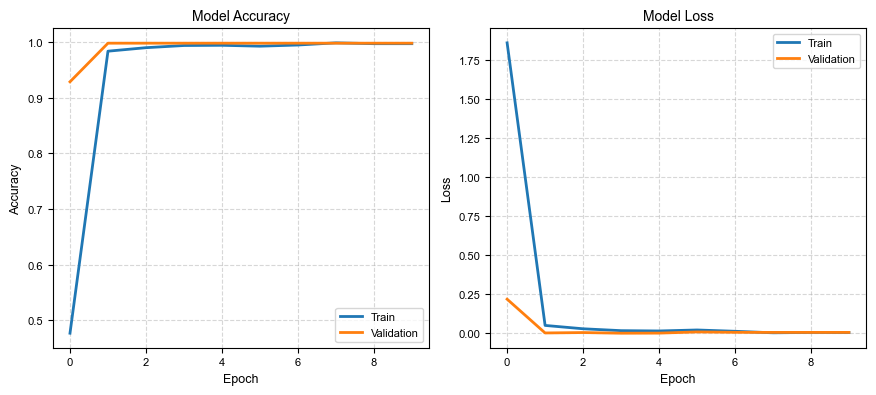

Figures exported successfully as cnn_training_history.eps matching Springer guidelines.


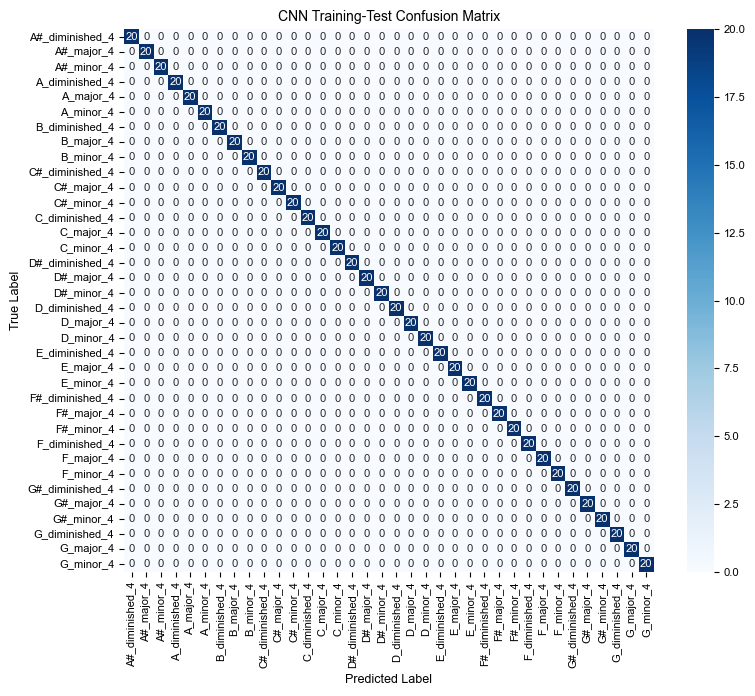

Figures exported successfully as cnn_training_confusion_matrix.eps matching Springer guidelines.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Training epoch graph (recreated from training output) ---
# Approximated from epoch logs: loss/accuracy curves over 10 epochs
epochs = np.arange(0, 10)
train_acc     = np.array([0.4765, 0.9841, 0.9904, 0.9943, 0.9947, 0.9931, 0.9952, 0.9991, 0.9976, 0.9976])
val_acc       = np.array([0.9290, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985])
train_loss    = np.array([1.8565, 0.0511, 0.0297, 0.0177, 0.0157, 0.0220, 0.0137, 0.0040, 0.0064, 0.0057])
val_loss      = np.array([0.2188, 0.0030, 0.0056, 0.0014, 0.0020, 0.0095, 0.0071, 0.0065, 0.0066, 0.0066])

fig, axes = plt.subplots(1, 2, figsize=(fig_width_inch * 1.6, fig_height_inch))

axes[0].plot(epochs, train_acc, label='Train', linewidth=2)
axes[0].plot(epochs, val_acc,   label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(epochs, train_loss, label='Train', linewidth=2)
axes[1].plot(epochs, val_loss,   label='Validation', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
export_plot("cnn_training_history")

# --- 2. Training-test confusion matrix (recreated from confusion matrix image) ---
# Per-class support: 20 samples each, 36 classes -> mostly 20 per cell, misclassifications as listed
class_labels = [
    'A#_diminished_4', 'A#_major_4', 'A#_minor_4',
    'A_diminished_4',  'A_major_4',  'A_minor_4',
    'B_diminished_4',  'B_major_4',  'B_minor_4',
    'C#_diminished_4', 'C#_major_4', 'C#_minor_4',
    'C_diminished_4',  'C_major_4',  'C_minor_4',
    'D#_diminished_4', 'D#_major_4', 'D#_minor_4',
    'D_diminished_4',  'D_major_4',  'D_minor_4',
    'E_diminished_4',  'E_major_4',  'E_minor_4',
    'F#_diminished_4', 'F#_major_4', 'F#_minor_4',
    'F_diminished_4',  'F_major_4',  'F_minor_4',
    'G#_diminished_4', 'G#_major_4', 'G#_minor_4',
    'G_diminished_4',  'G_major_4',  'G_minor_4',
]
n_classes = len(class_labels)
cm = np.eye(n_classes, dtype=int) * 20

import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('CNN Training-Test Confusion Matrix')
plt.tight_layout()
export_plot("cnn_training_confusion_matrix")

## CNN Cross Validation

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


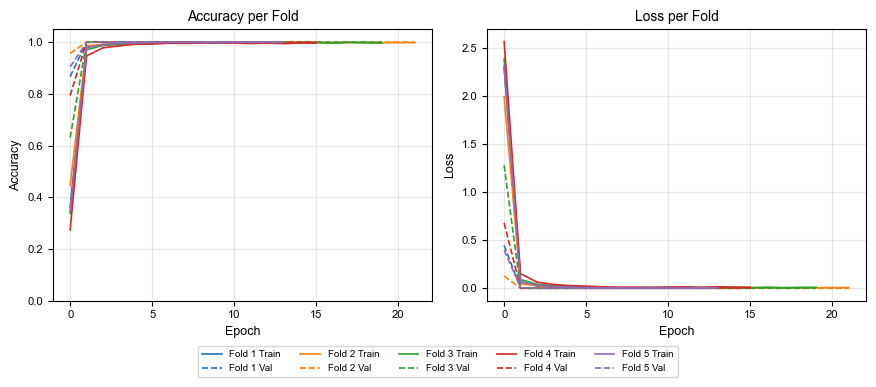

Figures exported successfully as cnn_kfold_training_history.eps matching Springer guidelines.


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Fold 1 (11 epochs) - early stop at epoch 11, best at epoch 5
f1_acc = [0.3623, 0.9790, 0.9919, 0.9938, 0.9969, 0.9967, 0.9986, 0.9985, 0.9992, 0.9988, 0.9979]
f1_val = [0.8663, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
f1_loss = [2.2914, 0.0658, 0.0227, 0.0239, 0.0104, 0.0082, 0.0036, 0.0036, 0.0032, 0.0032, 0.0051]
f1_vloss = [0.4460, 1.4033e-05, 3.6425e-06, 4.4792e-06, 2.5745e-07, 9.1270e-07, 9.7619e-07, 6.6051e-07, 6.4623e-07, 6.3817e-07, 8.0491e-07]

# Fold 2 (21 epochs) - early stop at epoch 21, best at epoch 15
f2_acc = [0.4460, 0.9855, 0.9909, 0.9950, 0.9944, 0.9975, 0.9985, 0.9979, 0.9975, 0.9986, 0.9979,
          0.9979, 0.9983, 0.9973, 0.9973, 0.9990, 0.9979, 0.9981, 0.9985, 0.9975, 0.9979, 0.9979]
f2_val = [0.9566, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
f2_loss = [1.9897, 0.0453, 0.0281, 0.0157, 0.0144, 0.0060, 0.0039, 0.0056, 0.0083, 0.0051, 0.0046,
          0.0064, 0.0088, 0.0079, 0.0095, 0.0049, 0.0050, 0.0063, 0.0050, 0.0049, 0.0074, 0.0063]
f2_vloss = [0.1270, 1.6564e-05, 2.0530e-07, 3.4913e-07, 4.7808e-08, 2.4214e-08, 2.0282e-08, 1.7799e-08, 1.8006e-08, 1.8006e-08, 1.7178e-08,
          1.6971e-08, 1.7385e-08, 1.7799e-08, 1.8006e-08, 1.5522e-08, 1.7592e-08, 1.6971e-08, 1.7799e-08, 1.8419e-08, 1.6557e-08, 1.5729e-08]

# Fold 3 (19 epochs) - early stop at epoch 19, best at epoch 13
f3_acc = [0.3372, 0.9705, 0.9869, 0.9911, 0.9959, 0.9977, 0.9965, 0.9977, 0.9986, 0.9975, 0.9967,
          0.9983, 0.9983, 0.9977, 0.9965, 0.9977, 0.9961, 0.9988, 0.9969, 0.9969]
f3_val = [0.6302, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
f3_loss = [2.3846, 0.0903, 0.0421, 0.0266, 0.0138, 0.0070, 0.0099, 0.0061, 0.0045, 0.0080, 0.0088,
          0.0068, 0.0061, 0.0079, 0.0095, 0.0065, 0.0108, 0.0053, 0.0091, 0.0091]
f3_vloss = [1.2776, 2.7744e-05, 8.8070e-06, 7.6903e-07, 1.1259e-07, 1.5563e-07, 1.0369e-07, 7.4299e-08, 7.2229e-08, 7.0780e-08, 7.0366e-08,
          7.0780e-08, 6.9125e-08, 7.0780e-08, 7.3471e-08, 7.2643e-08, 7.2229e-08, 6.9746e-08, 7.1608e-08, 7.1608e-08]

# Fold 4 (15 epochs) - early stop at epoch 15, best at epoch 9
f4_acc = [0.2733, 0.9464, 0.9780, 0.9855, 0.9917, 0.9923, 0.9958, 0.9952, 0.9959, 0.9969, 0.9963,
          0.9944, 0.9965, 0.9942, 0.9967, 0.9963]
f4_val = [0.7934, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
f4_loss = [2.5646, 0.1518, 0.0639, 0.0399, 0.0277, 0.0220, 0.0144, 0.0109, 0.0113, 0.0093, 0.0121,
          0.0141, 0.0089, 0.0157, 0.0104, 0.0104]
f4_vloss = [0.6791, 1.6404e-04, 1.6505e-06, 2.5083e-07, 2.2145e-08, 3.1044e-09, 2.6905e-09, 1.4487e-09, 1.0348e-09, 1.0348e-09, 1.2418e-09,
          1.0348e-09, 1.0348e-09, 1.0348e-09, 1.0348e-09, 1.0348e-09]

# Fold 5 (14 epochs) - early stop at epoch 14, best at epoch 8
f5_acc = [0.3476, 0.9799, 0.9890, 0.9954, 0.9967, 0.9983, 0.9988, 0.9988, 0.9986, 0.9985, 0.9992,
          0.9994, 0.9996, 0.9985]
f5_val = [0.9045, 0.9983, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000]
f5_loss = [2.3115, 0.0658, 0.0341, 0.0159, 0.0106, 0.0058, 0.0040, 0.0034, 0.0036, 0.0041, 0.0036,
          0.0019, 0.0024, 0.0058]
f5_vloss = [0.3974, 0.0071, 1.3650e-05, 5.7328e-08, 3.7046e-08, 1.0555e-08, 2.8974e-09, 2.4835e-09, 2.6905e-09, 2.6905e-09, 2.4835e-09,
          2.6905e-09, 2.6905e-09, 2.8974e-09]

# Normalize loss to log scale for better visualization (clip very small values to display floor)
# loss_floor = 1e-9
folds_acc = [f1_acc, f2_acc, f3_acc, f4_acc, f5_acc]
folds_val = [f1_val, f2_val, f3_val, f4_val, f5_val]
folds_loss = [f1_loss, f2_loss, f3_loss, f4_loss, f5_loss]
folds_vloss = [f1_vloss, f2_vloss, f3_vloss, f4_vloss, f5_vloss]

fig, axes = plt.subplots(1, 2, figsize=(fig_width_inch * 1.6, fig_height_inch))

color_map = plt.get_cmap('tab10')
for i, (acc, val_acc) in enumerate(zip(folds_acc, folds_val)):
    epochs = np.arange(len(acc))
    axes[0].plot(epochs, acc,     color=color_map(i), label=f'Fold {i+1} Train', linewidth=1.2)
    axes[0].plot(epochs, val_acc, color=color_map(i), linestyle='--', label=f'Fold {i+1} Val', linewidth=1.2)
for i, (loss, val_loss) in enumerate(zip(folds_loss, folds_vloss)):
    epochs = np.arange(len(loss))
    axes[1].plot(epochs, loss,     color=color_map(i), label=f'Fold {i+1} Train', linewidth=1.2)
    axes[1].plot(epochs, val_loss, color=color_map(i), linestyle='--', label=f'Fold {i+1} Val', linewidth=1.2)

axes[0].set_title('Accuracy per Fold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Loss per Fold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
# axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0.04), fontsize=7)
plt.tight_layout(rect=[0, 0.12, 1, 1])
export_plot("cnn_kfold_training_history")

# CNN vs. SVM Evaluation

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


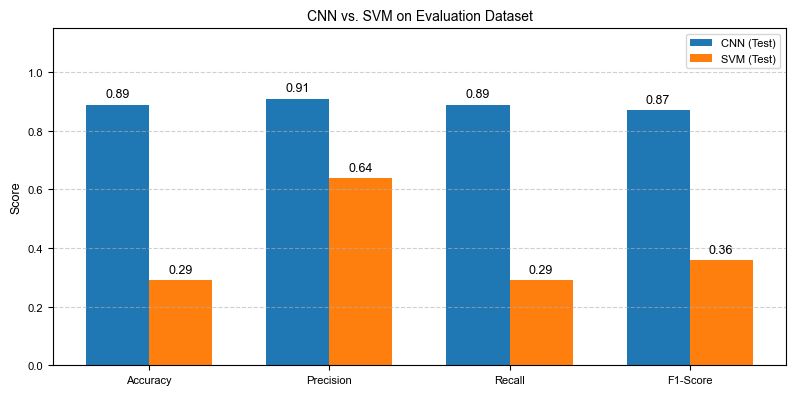

Figures exported successfully as cnn_vs_svm_evaluation_dataset.eps matching Springer guidelines.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Data from Table-IX: CNN vs. SVM on Cross-Validation and Test Set Evaluation
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_validation = [1.00, 1.00, 1.00, 1.00]
cnn_test       = [0.89, 0.91, 0.89, 0.87]
svm_validation = [1.00, 1.00, 1.00, 1.00]
svm_test       = [0.29, 0.64, 0.29, 0.36]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, cnn_test, width, label='CNN (Test)')
bars2 = ax.bar(x + width/2, svm_test, width, label='SVM (Test)')

# Annotate bars with their values
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('CNN vs. SVM on Evaluation Dataset')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
export_plot("cnn_vs_svm_evaluation_dataset")